In [1]:
!pip install -q huggingface_hub openai pandas matplotlib seaborn

In [2]:
from openai import OpenAI
import os
from dotenv import load_dotenv

load_dotenv(override=True)
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

print("Key loaded:", GROQ_API_KEY[:10] + "...")
print("Key length:", len(GROQ_API_KEY))

MODEL = "llama-3.3-70b-versatile"

client = OpenAI(
    base_url="https://api.groq.com/openai/v1",
    api_key=GROQ_API_KEY,
)

# Quick test
resp = client.chat.completions.create(
    model=MODEL,
    messages=[{"role": "user", "content": "Say hello in one sentence."}],
    max_tokens=50,
)
print("\nModel response:", resp.choices[0].message.content)

Key loaded: gsk_EIxUqK...
Key length: 56

Model response: Hello, it's nice to meet you and I'm here to help with any questions or topics you'd like to discuss.


In [6]:
import pandas as pd
import io

# ── Date preprocessor ─────────────────────────────────────────────
def preprocess_dates(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    date_columns = []

    for col in df.columns:
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            date_columns.append(col)
            continue
        if any(x in col.lower() for x in ['date', 'time', 'day']):
            try:
                df[col] = pd.to_datetime(df[col], errors='coerce')
                if df[col].notna().sum() > 0:
                    date_columns.append(col)
            except:
                pass

    for col in date_columns:
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            df[f'{col}_year']       = df[col].dt.year
            df[f'{col}_month']      = df[col].dt.month
            df[f'{col}_year_month'] = df[col].dt.to_period('M').astype(str)

    return df

# ── Schema description ────────────────────────────────────────────
def get_schema_description(df: pd.DataFrame, max_rows: int = 3) -> str:
    schema_lines = ["Columns:"]
    for col, dtype in df.dtypes.items():
        if dtype == 'object' and df[col].nunique() < 20:
            unique_vals = df[col].dropna().unique()[:5]
            schema_lines.append(
                f"- {col} ({dtype}) - sample values: {', '.join(map(str, unique_vals))}"
            )
        else:
            schema_lines.append(f"- {col} ({dtype})")

    # to_string() — no tabulate needed
    sample = df.head(max_rows).to_string(index=False)
    return "\n".join(schema_lines) + "\n\nSample rows:\n" + sample



print("✅ preprocess_dates and get_schema_description defined")

✅ preprocess_dates and get_schema_description defined


In [7]:
!pip install tabulate

Defaulting to user installation because normal site-packages is not writeable


In [8]:
# Create a sample sales CSV to test with
sample_csv = """Order Date,Category,Product,Sales,Quantity
2023-01-15,Furniture,Chair,450.00,2
2023-02-20,Technology,Phone,899.99,1
2023-03-10,Office Supplies,Paper,29.99,10
2023-06-18,Furniture,Desk,750.00,1
2023-08-05,Technology,Laptop,1299.99,1
2022-11-12,Office Supplies,Pen,9.99,50
2022-12-01,Technology,Tablet,499.99,3
2022-05-22,Furniture,Bookshelf,320.00,2
"""

df = pd.read_csv(io.StringIO(sample_csv))
df = preprocess_dates(df)

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nSchema:\n")
print(get_schema_description(df))

Shape: (8, 8)

Columns: ['Order Date', 'Category', 'Product', 'Sales', 'Quantity', 'Order Date_year', 'Order Date_month', 'Order Date_year_month']

Schema:

Columns:
- Order Date (datetime64[us])
- Category (str)
- Product (str)
- Sales (float64)
- Quantity (int64)
- Order Date_year (int32)
- Order Date_month (int32)
- Order Date_year_month (str)

Sample rows:
Order Date        Category Product  Sales  Quantity  Order Date_year  Order Date_month Order Date_year_month
2023-01-15       Furniture   Chair 450.00         2             2023                 1               2023-01
2023-02-20      Technology   Phone 899.99         1             2023                 2               2023-02
2023-03-10 Office Supplies   Paper  29.99        10             2023                 3               2023-03


In [9]:
import json
import re

def call_planner_llm(schema_text: str, question: str) -> dict:
    system_prompt = """
You are a data analysis planner. Convert user questions into JSON plans.

JSON Structure (REQUIRED - output ONLY this JSON, nothing else):
{
  "operation": "group_by_summary",
  "group_by": ["column_name"],
  "filters": [],
  "target_column": "column_to_analyze",
  "metric": "sum",
  "need_chart": true,
  "chart_type": "bar"
}

Fields:
- operation: Always use "group_by_summary"
- group_by: Columns to group by (e.g. ["Category"] or ["Category", "Product"])
- filters: Optional filters e.g. [{"column": "Order Date_year", "op": "==", "value": 2023}]
- target_column: Column to aggregate (must exist in schema!)
- metric: One of: sum, mean, count, max, min
- need_chart: true always
- chart_type: bar, line, or pie

Rules:
- Use ONLY columns from the provided schema
- For time-based questions use Order Date_year or Order Date_year_month
- Output ONLY the JSON — no explanation, no markdown, no extra text
""".strip()

    messages = [
        {"role": "system", "content": system_prompt},
        {
            "role": "user",
            "content": f"Dataset:\n{schema_text}\n\nQuestion:\n{question}"
        },
    ]

    resp = client.chat.completions.create(
        model=MODEL,
        messages=messages,
        max_tokens=512,
        temperature=0,
    )

    content = resp.choices[0].message.content.strip()

    # Extract JSON robustly
    def extract_json(text):
        # Try direct parse
        try:
            return json.loads(text)
        except:
            pass
        # Try extracting from code block
        match = re.search(r'```(?:json)?\s*(\{.*?\})\s*```', text, re.DOTALL)
        if match:
            try:
                return json.loads(match.group(1))
            except:
                pass
        # Try finding first { ... }
        match = re.search(r'\{.*\}', text, re.DOTALL)
        if match:
            try:
                return json.loads(match.group())
            except:
                pass
        raise ValueError(f"Could not extract JSON from response:\n{text}")

    plan = extract_json(content)
    return plan

print("✅ call_planner_llm defined")

✅ call_planner_llm defined


In [10]:
schema_text = get_schema_description(df)
question = "Which category had the highest total sales?"

plan = call_planner_llm(schema_text, question)
print("Plan returned:\n")
print(json.dumps(plan, indent=2))

Plan returned:

{
  "operation": "group_by_summary",
  "group_by": [
    "Category"
  ],
  "filters": [],
  "target_column": "Sales",
  "metric": "sum",
  "need_chart": true,
  "chart_type": "bar"
}


In [11]:
def apply_filters(df: pd.DataFrame, filters: list) -> pd.DataFrame:
    if not filters:
        return df
    filtered = df.copy()
    for f in filters:
        col = f.get("column")
        op  = f.get("op")
        val = f.get("value")
        if col not in filtered.columns:
            print(f"⚠️ Filter column '{col}' not found, skipping.")
            continue
        try:
            val_cast = pd.to_numeric(val)
        except:
            val_cast = val
        if op == "==":   filtered = filtered[filtered[col] == val_cast]
        elif op == "!=": filtered = filtered[filtered[col] != val_cast]
        elif op == ">":  filtered = filtered[filtered[col] > val_cast]
        elif op == "<":  filtered = filtered[filtered[col] < val_cast]
        elif op == ">=": filtered = filtered[filtered[col] >= val_cast]
        elif op == "<=": filtered = filtered[filtered[col] <= val_cast]
        elif op == "contains":
            filtered = filtered[filtered[col].astype(str).str.contains(str(val_cast), case=False, na=False)]
    return filtered


def run_analysis_plan(df: pd.DataFrame, plan: dict) -> pd.DataFrame:
    op         = plan.get("operation")
    target_col = plan.get("target_column")
    group_by   = plan.get("group_by") or []
    filters    = plan.get("filters") or []
    metric     = plan.get("metric", "sum")

    # Apply filters first
    if filters:
        df = apply_filters(df, filters)

    # Validate target column
    if not target_col or target_col not in df.columns:
        print(f"⚠️ Target column '{target_col}' not found. Returning preview.")
        return df.head(10)

    # No group_by — aggregate whole column
    if not group_by:
        if metric == "sum":   value = df[target_col].sum()
        elif metric == "mean": value = df[target_col].mean()
        elif metric == "count": value = df[target_col].count()
        elif metric == "max":  value = df[target_col].max()
        elif metric == "min":  value = df[target_col].min()
        return pd.DataFrame({f"{metric}_{target_col}": [value]})

    # Group by + aggregate
    agg_funcs = {
        "sum": "sum", "mean": "mean",
        "count": "count", "max": "max", "min": "min"
    }
    agg_df = (
        df.groupby(group_by)[target_col]
        .agg(agg_funcs.get(metric, "sum"))
        .reset_index()
        .sort_values(by=target_col, ascending=False)
    )
    return agg_df

print("✅ apply_filters and run_analysis_plan defined")

✅ apply_filters and run_analysis_plan defined


In [12]:
result_df = run_analysis_plan(df, plan)
print("Result:\n")
print(result_df.to_string(index=False))

Result:

       Category   Sales
     Technology 2699.97
      Furniture 1520.00
Office Supplies   39.98


In [15]:
def generate_chart(df: pd.DataFrame, plan: dict):
    if not plan.get("need_chart") or df.empty:
        return None

    chart_type = plan.get("chart_type", "bar")
    group_by   = plan.get("group_by") or []
    target_col = plan.get("target_column")
    metric     = plan.get("metric", "sum")  # ← fixed here

    if not target_col or target_col not in df.columns:
        return None

    fig, ax = plt.subplots(figsize=(10, 6))

    if group_by and len(group_by) > 0:
        x_col   = group_by[0]
        plot_df = df.head(15)

        if chart_type == "bar":
            colors = sns.color_palette("husl", len(plot_df))
            bars = ax.bar(range(len(plot_df)), plot_df[target_col], color=colors)
            ax.set_xticks(range(len(plot_df)))
            ax.set_xticklabels(plot_df[x_col], rotation=45, ha='right')
            ax.set_ylabel(target_col, fontsize=12)
            ax.set_xlabel(x_col, fontsize=12)
            for bar, val in zip(bars, plot_df[target_col]):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height(),
                    f'{val:,.2f}',
                    ha='center', va='bottom', fontsize=10
                )

        elif chart_type == "line":
            ax.plot(range(len(plot_df)), plot_df[target_col],
                    marker='o', linewidth=2, markersize=8)
            ax.set_xticks(range(len(plot_df)))
            ax.set_xticklabels(plot_df[x_col], rotation=45, ha='right')
            ax.set_ylabel(target_col, fontsize=12)
            ax.set_xlabel(x_col, fontsize=12)

        elif chart_type == "pie" and len(plot_df) <= 10:
            ax.pie(plot_df[target_col], labels=plot_df[x_col],
                   autopct='%1.1f%%', startangle=90)
            ax.axis('equal')

        title = f"{metric.upper()} of {target_col} by {x_col}"
    else:
        ax.bar([target_col], [df[target_col].iloc[0]])
        title = f"{target_col}"

    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    fig.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=150, bbox_inches='tight')
    buf.seek(0)
    plt.close(fig)
    return buf

print("✅ generate_chart defined")

✅ generate_chart defined


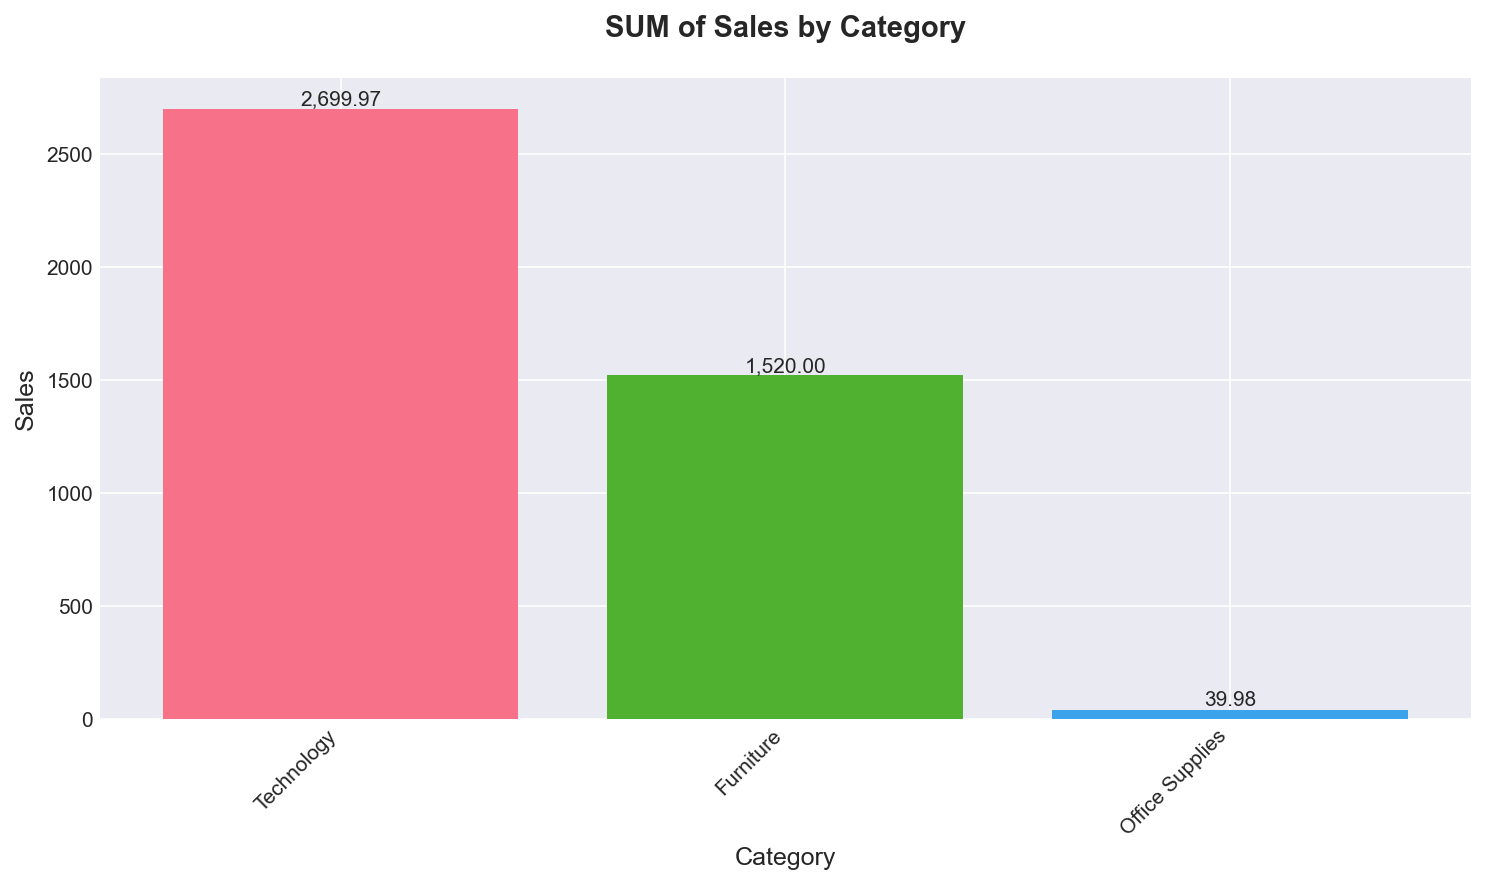

✅ Chart generated successfully


In [16]:
from IPython.display import Image, display

chart_buf = generate_chart(result_df, plan)

if chart_buf:
    display(Image(data=chart_buf.getvalue()))
    print("✅ Chart generated successfully")
else:
    print("⚠️ No chart generated")

In [17]:
def call_explainer_llm(question: str, plan: dict, result_df: pd.DataFrame) -> str:
    # Convert result to a simple string for the prompt
    result_summary = result_df.head(20).to_string(index=False)

    system_prompt = """
You are a senior data analyst explaining insights to business stakeholders.
You will receive a question, the analysis plan that was executed, and the results.

Your response must:
- Start with a direct 1-2 sentence answer to the question
- Use 3-5 bullet points highlighting key insights with specific numbers
- Use simple business language — no technical jargon
- End with one short recommendation or next step

Keep it concise and actionable.
""".strip()

    user_content = f"""
Question: {question}

Analysis performed:
{json.dumps(plan, indent=2)}

Results:
{result_summary}
""".strip()

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user",   "content": user_content},
    ]

    resp = client.chat.completions.create(
        model=MODEL,
        messages=messages,
        max_tokens=512,
        temperature=0.3,
    )

    return resp.choices[0].message.content.strip()

print("✅ call_explainer_llm defined")

✅ call_explainer_llm defined


In [18]:
explanation = call_explainer_llm(question, plan, result_df)
print("AI Insights:\n")
print(explanation)

AI Insights:

The Technology category had the highest total sales. This is based on the analysis of sales data across different categories.

* Technology sales totaled $2,699.97, accounting for the largest share of sales.
* Furniture sales came in second, with total sales of $1,520.00.
* Office Supplies had the lowest sales, with a total of $39.98.
* The Technology category outsold Furniture by $1,179.97, a significant margin.
* The top two categories, Technology and Furniture, combined for over 95% of total sales.

We recommend focusing on the Technology category for future sales growth initiatives.


In [19]:
def run_pipeline(df: pd.DataFrame, question: str):
    print(f"Question: {question}")
    print("-" * 50)

    # Step 1 — Build schema
    schema_text = get_schema_description(df)

    # Step 2 — Planner Agent
    print("🤖 Planner Agent thinking...")
    plan = call_planner_llm(schema_text, question)
    print("Plan:", json.dumps(plan, indent=2))
    print("-" * 50)

    # Step 3 — Data Worker
    print("🔧 Data Worker executing plan...")
    result_df = run_analysis_plan(df, plan)
    print("Result:")
    print(result_df.to_string(index=False))
    print("-" * 50)

    # Step 4 — Chart Generator
    print("📊 Generating chart...")
    chart_buf = generate_chart(result_df, plan)
    if chart_buf:
        display(Image(data=chart_buf.getvalue()))

    # Step 5 — Explainer Agent
    print("💡 Explainer Agent generating insights...")
    explanation = call_explainer_llm(question, plan, result_df)
    print("\nAI Insights:")
    print(explanation)
    print("-" * 50)

    return plan, result_df, explanation

print("✅ run_pipeline defined")

✅ run_pipeline defined


Question: Which category had the highest total sales?
--------------------------------------------------
🤖 Planner Agent thinking...
Plan: {
  "operation": "group_by_summary",
  "group_by": [
    "Category"
  ],
  "filters": [],
  "target_column": "Sales",
  "metric": "sum",
  "need_chart": true,
  "chart_type": "bar"
}
--------------------------------------------------
🔧 Data Worker executing plan...
Result:
       Category   Sales
     Technology 2699.97
      Furniture 1520.00
Office Supplies   39.98
--------------------------------------------------
📊 Generating chart...


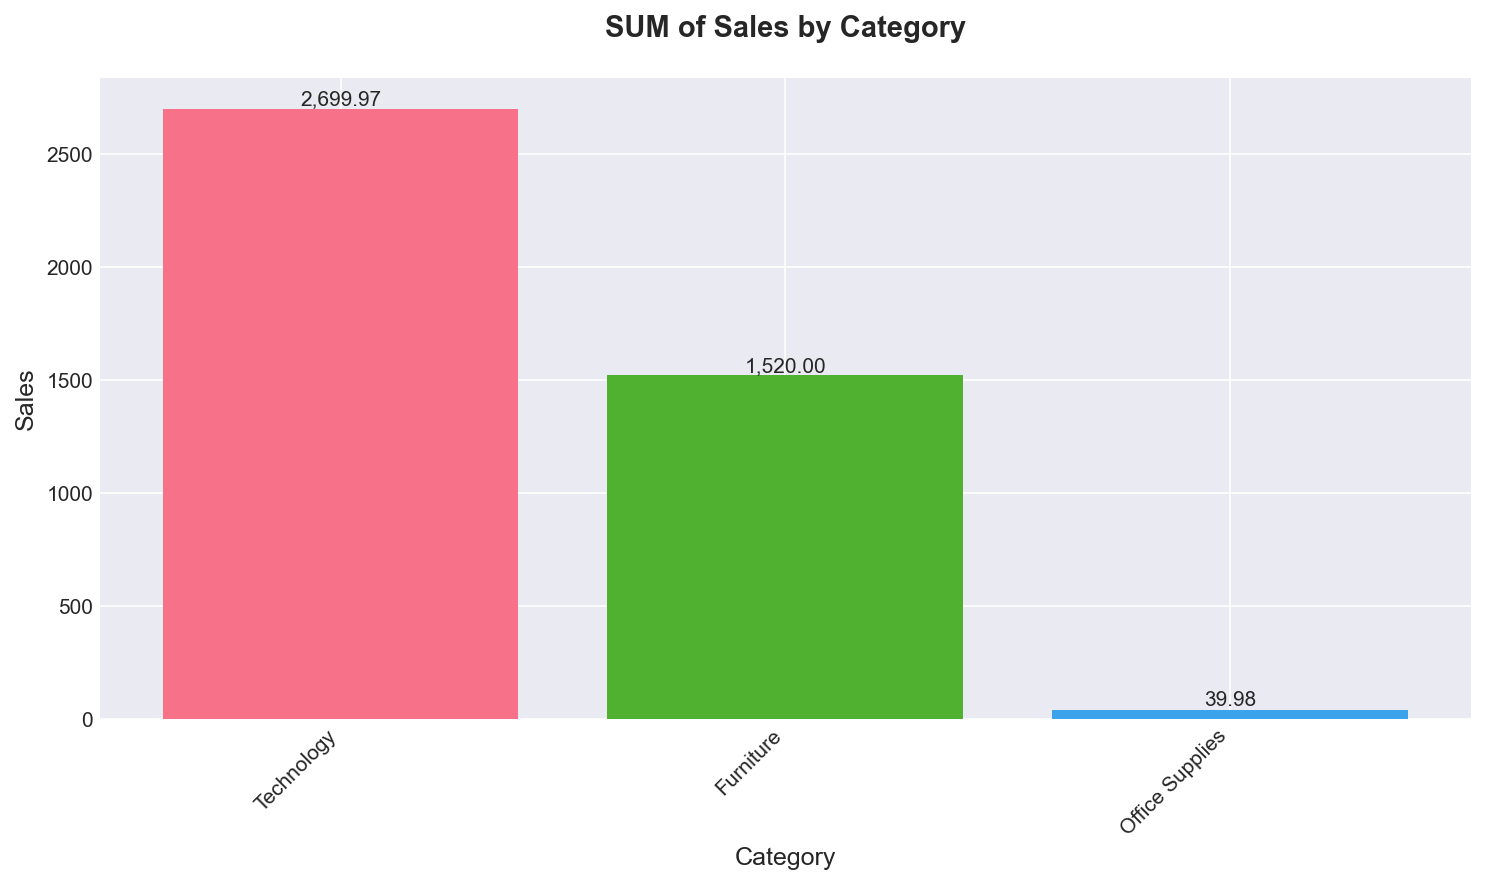

💡 Explainer Agent generating insights...

AI Insights:
The Technology category had the highest total sales. This is based on the analysis of sales data across different categories.

* Technology category sales totaled $2,699.97, accounting for the largest share of sales.
* Furniture category sales were $1,520.00, significantly lower than Technology.
* Office Supplies had the lowest sales, totaling only $39.98.
* The top two categories, Technology and Furniture, combined for over 95% of total sales.
* The large gap between Technology and Furniture sales suggests a strong demand for tech products.

We should focus on expanding our Technology product offerings to capitalize on this demand.
--------------------------------------------------


({'operation': 'group_by_summary',
  'group_by': ['Category'],
  'filters': [],
  'target_column': 'Sales',
  'metric': 'sum',
  'need_chart': True,
  'chart_type': 'bar'},
           Category    Sales
 2       Technology  2699.97
 0        Furniture  1520.00
 1  Office Supplies    39.98,
 'The Technology category had the highest total sales. This is based on the analysis of sales data across different categories.\n\n* Technology category sales totaled $2,699.97, accounting for the largest share of sales.\n* Furniture category sales were $1,520.00, significantly lower than Technology.\n* Office Supplies had the lowest sales, totaling only $39.98.\n* The top two categories, Technology and Furniture, combined for over 95% of total sales.\n* The large gap between Technology and Furniture sales suggests a strong demand for tech products.\n\nWe should focus on expanding our Technology product offerings to capitalize on this demand.')

In [20]:
from IPython.display import Image, display

# Test 1
run_pipeline(df, "Which category had the highest total sales?")

Question: What were the total sales per month in 2023?
--------------------------------------------------
🤖 Planner Agent thinking...
Plan: {
  "operation": "group_by_summary",
  "group_by": [
    "Order Date_year_month"
  ],
  "filters": [
    {
      "column": "Order Date_year",
      "op": "==",
      "value": 2023
    }
  ],
  "target_column": "Sales",
  "metric": "sum",
  "need_chart": true,
  "chart_type": "bar"
}
--------------------------------------------------
🔧 Data Worker executing plan...
Result:
Order Date_year_month   Sales
              2023-08 1299.99
              2023-02  899.99
              2023-06  750.00
              2023-01  450.00
              2023-03   29.99
--------------------------------------------------
📊 Generating chart...


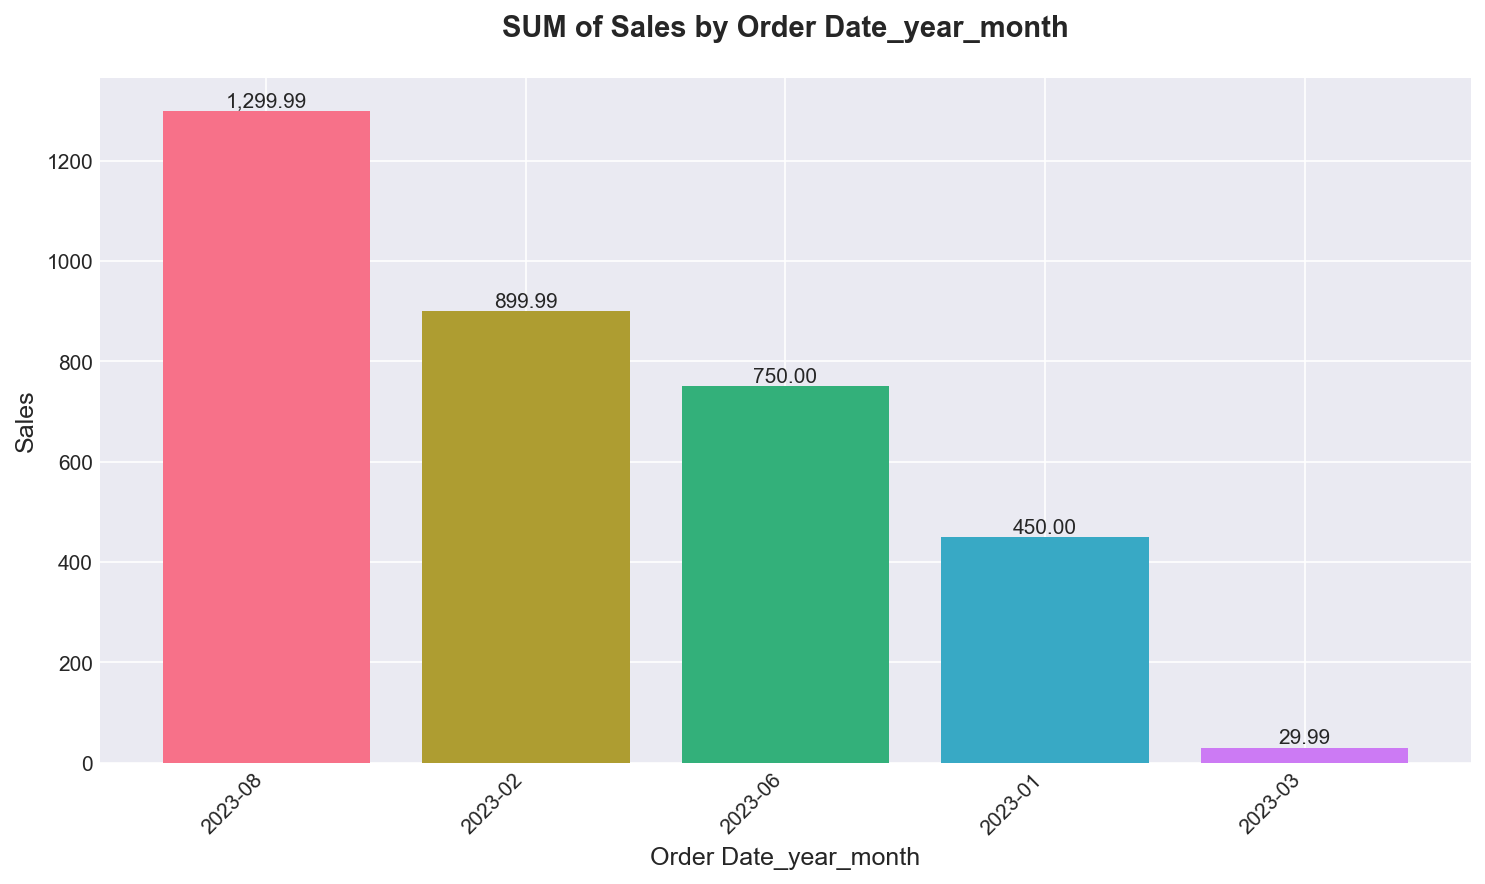

💡 Explainer Agent generating insights...

AI Insights:
The total sales per month in 2023 varied, with the highest sales in August. Here are the key insights: 
* August 2023 had the highest sales at $1,299.99
* February 2023 had the second-highest sales at $899.99
* The lowest sales were in March 2023 at $29.99
* The total sales for the top 3 months (August, February, and June) were $3,049.98
* The average monthly sales for the months with data were $746.19

I recommend reviewing the sales strategy for March to identify opportunities for improvement.
--------------------------------------------------


({'operation': 'group_by_summary',
  'group_by': ['Order Date_year_month'],
  'filters': [{'column': 'Order Date_year', 'op': '==', 'value': 2023}],
  'target_column': 'Sales',
  'metric': 'sum',
  'need_chart': True,
  'chart_type': 'bar'},
   Order Date_year_month    Sales
 4               2023-08  1299.99
 1               2023-02   899.99
 3               2023-06   750.00
 0               2023-01   450.00
 2               2023-03    29.99,
 'The total sales per month in 2023 varied, with the highest sales in August. Here are the key insights: \n* August 2023 had the highest sales at $1,299.99\n* February 2023 had the second-highest sales at $899.99\n* The lowest sales were in March 2023 at $29.99\n* The total sales for the top 3 months (August, February, and June) were $3,049.98\n* The average monthly sales for the months with data were $746.19\n\nI recommend reviewing the sales strategy for March to identify opportunities for improvement.')

In [21]:
# Test 2
run_pipeline(df, "What were the total sales per month in 2023?")

Question: Which product had the highest sales?
--------------------------------------------------
🤖 Planner Agent thinking...
Plan: {
  "operation": "group_by_summary",
  "group_by": [
    "Product"
  ],
  "filters": [],
  "target_column": "Sales",
  "metric": "sum",
  "need_chart": true,
  "chart_type": "bar"
}
--------------------------------------------------
🔧 Data Worker executing plan...
Result:
  Product   Sales
   Laptop 1299.99
    Phone  899.99
     Desk  750.00
   Tablet  499.99
    Chair  450.00
Bookshelf  320.00
    Paper   29.99
      Pen    9.99
--------------------------------------------------
📊 Generating chart...


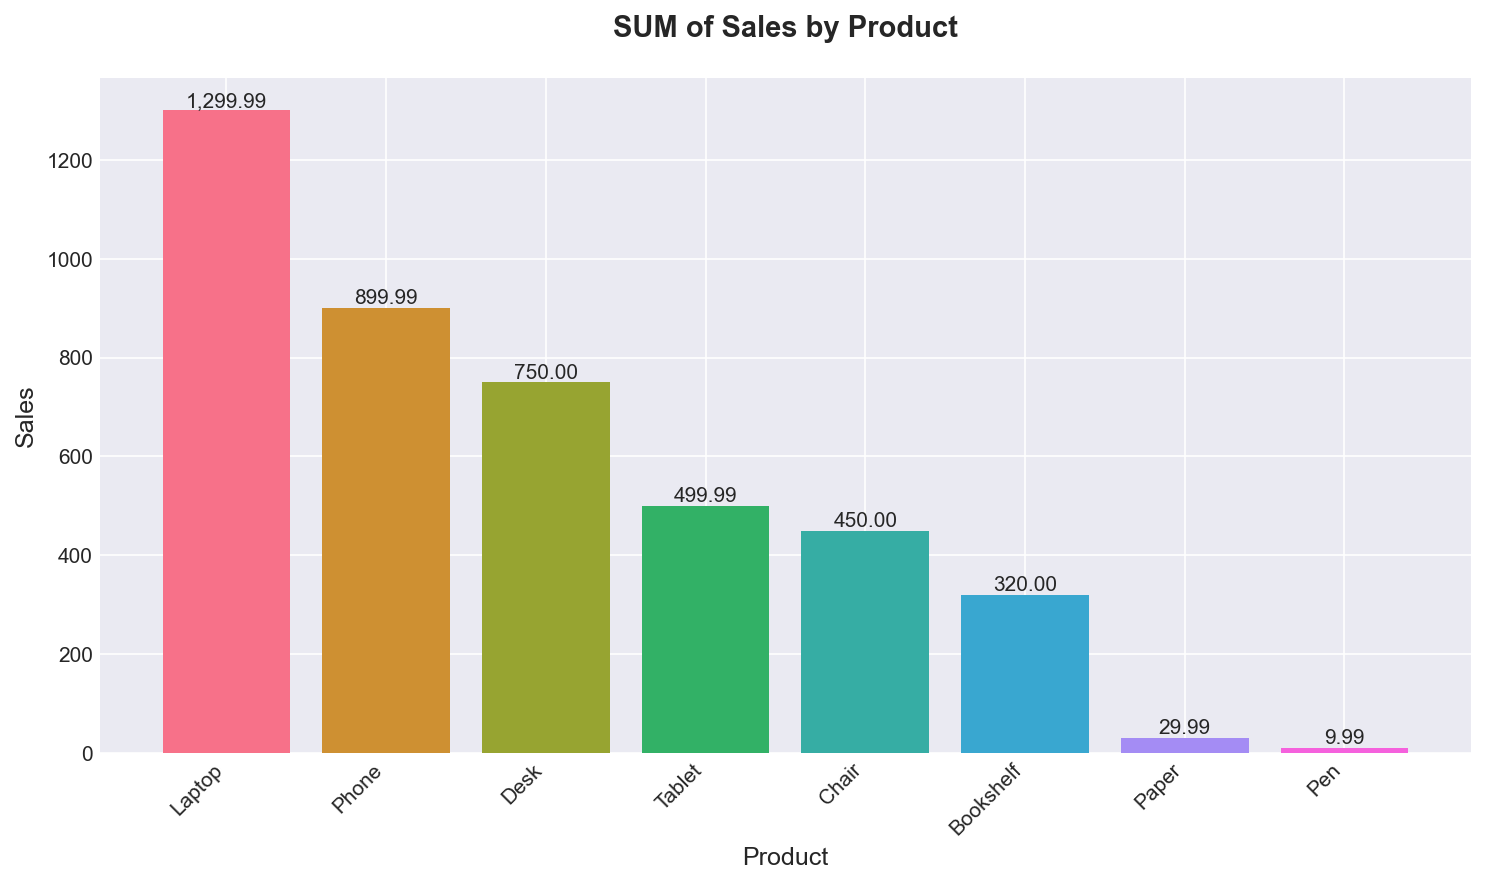

💡 Explainer Agent generating insights...

AI Insights:
The product with the highest sales is the Laptop, with total sales of $1299.99. This is significantly higher than the other products.

* Laptop sales were $1299.99, accounting for the largest share of total sales.
* Phone sales followed closely, with total sales of $899.99.
* Desk sales were $750.00, making it the third best-selling product.
* The top three products (Laptop, Phone, and Desk) accounted for over 75% of total sales.
* The remaining products (Tablet, Chair, Bookshelf, Paper, and Pen) had relatively low sales, totaling less than $1250 combined.

We should consider increasing our marketing efforts for Laptops to further capitalize on their popularity.
--------------------------------------------------


({'operation': 'group_by_summary',
  'group_by': ['Product'],
  'filters': [],
  'target_column': 'Sales',
  'metric': 'sum',
  'need_chart': True,
  'chart_type': 'bar'},
      Product    Sales
 3     Laptop  1299.99
 6      Phone   899.99
 2       Desk   750.00
 7     Tablet   499.99
 1      Chair   450.00
 0  Bookshelf   320.00
 4      Paper    29.99
 5        Pen     9.99,
 'The product with the highest sales is the Laptop, with total sales of $1299.99. This is significantly higher than the other products.\n\n* Laptop sales were $1299.99, accounting for the largest share of total sales.\n* Phone sales followed closely, with total sales of $899.99.\n* Desk sales were $750.00, making it the third best-selling product.\n* The top three products (Laptop, Phone, and Desk) accounted for over 75% of total sales.\n* The remaining products (Tablet, Chair, Bookshelf, Paper, and Pen) had relatively low sales, totaling less than $1250 combined.\n\nWe should consider increasing our marketing ef

In [22]:
# Test 3
run_pipeline(df, "Which product had the highest sales?")